# Heavy Equipment Selling Price Prediction

The goal of this project is to predict the selling price of heavy equipment using historical transaction, machine specification, usage, and categorical information. The evaluation metric is RMSLE, which penalizes relative error and is suitable for price prediction problems.

In [1]:
import numpy as np 
import pandas as pd 
#Visualizations
import matplotlib.pyplot as plt
import seaborn as sns
#Preprocessing
from sklearn.model_selection import train_test_split
import re
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
#Evaluation Metrics
from sklearn.metrics import mean_squared_log_error
#Models
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

In [2]:
train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv', low_memory=False)

**Feature Renaming**

The dataset contained several anonymized columns named **col1 to col30**. The competition organizers provided a metadata file describing these attributes. To improve readability, make feature importance easier to interpret, and simplify the analysis, I renamed these columns using the official metadata. The underlying data remained unchanged; only the column names were made more descriptive.

In [3]:
rename_cols = {"col1": "drive_system_config","col3": "stabilization_subsystem","col4": "extension_arm_layout",
               "col5": "engine_intake_type","col6": "extension_module_status","col7": "working_component_width",
               "col8": "protective_housing_specs","col9": "rated_power_output","col10": "hydraulic_system_class",
               "col11": "shock_absorption_interface","col12": "piercing_accessories","col13": "finishing_accessories",
               "col14": "actuator_control_logic","col15": "wheel_dimensions","col16": "coupling_mechanism",
               "col18": "traction_system_type","col19": "fluid_flow_rate","col20": "tread_pattern",
               "col21": "ground_contact_width","col22": "max_arm_reach","col23": "material_retention_design",
               "col24": "control_logic_map","col25": "traction_profile","col27": "attached_tool_category",
               "col28": "steering_input_config","col29": "differential_type","col30": "primary_steering_interface"
}
train = train.rename(columns=rename_cols)
test = test.rename(columns=rename_cols)

In [4]:
# For Final Model training
train_raw = train.copy()
test_raw = test.copy()

## 1. EDA (Exploratory Data Analysis)

### 1.1. Dataset Overview

In [5]:
train.head()

,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,tread_pattern,ground_contact_width,max_arm_reach,material_retention_design,control_logic_map,traction_profile,attached_tool_category,steering_input_config,differential_type,primary_steering_interface
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


In [6]:
train.shape

(138701, 50)

In [7]:
test.shape

(15000, 49)

- Highly Categorical Dataset
   - Numeric columns = 6
   - Categorical Columns = 44

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   TransactionID               138701 non-null  int64  
 1   TargetValue                 138701 non-null  float64
 2   AssetID                     138701 non-null  int64  
 3   ProductConfigID             138701 non-null  int64  
 4   DataOriginCode              138701 non-null  object 
 5   VendorPartnerID             138701 non-null  object 
 6   ManufactureYear             138701 non-null  int64  
 7   OperationalHoursMeter       82058 non-null   float64
 8   UtilizationTier             50475 non-null   object 
 9   TransactionDate             138701 non-null  object 
 10  Spec_FullDescriptor         138701 non-null  object 
 11  Spec_BaseClass              138701 non-null  object 
 12  Spec_SubClass               101716 non-null  object 
 13  Spec_ReleaseSe

In [9]:
train.describe()

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


### 1.2. **Missing Value Analysis**
- We first inspect the percentage of missing values in each feature to understand data quality and identify columns that may require imputation or feature engineering.
  
- Columns **fluid_flow_rate** and **traction_system_type** have approximately **99.95% missing values**, with only 66 non-null observations out of 138,701 records. Such a small amount of available information suggests these columns may contribute little predictive value and are potential candidates for removal during preprocessing.

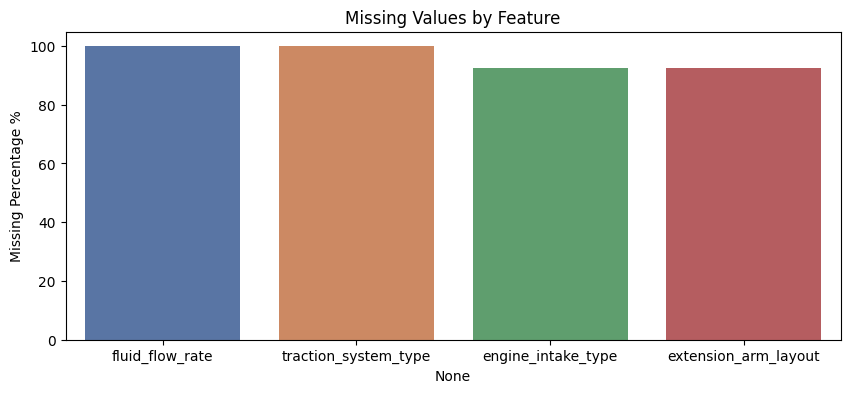

In [10]:
missing = (train.isnull().mean().sort_values(ascending=False)* 100)

missing = missing[missing > 90]
plt.figure(figsize=(10,4))
sns.barplot(x=missing.index, y=missing.values, hue=missing.index, palette='deep')
plt.ylabel("Missing Percentage %")
plt.title("Missing Values by Feature")
plt.show()

In [11]:
missing_pct = (train.isnull().sum() / len(train))*100

missing_pct.sort_values(ascending=False).head(15)

fluid_flow_rate               99.952416
traction_system_type          99.952416
engine_intake_type            92.515555
extension_arm_layout          92.515555
attached_tool_category        89.214930
steering_input_config         89.214930
differential_type             86.393753
primary_steering_interface    86.393753
finishing_accessories         83.125572
actuator_control_logic        83.125572
working_component_width       83.125572
extension_module_status       83.125572
rated_power_output            83.125572
protective_housing_specs      83.125572
shock_absorption_interface    83.125572
dtype: float64

In [12]:
# Checking for any duplicates 
train.duplicated().sum()

np.int64(0)

### 1.3. **Target Value Analysis**

Understanding the distribution of the target variable helps determine whether transformations are required before model training.

Observations:
- The target variable is **positively skewed** with a long right tail, indicating that higher-valued assets are relatively rare.

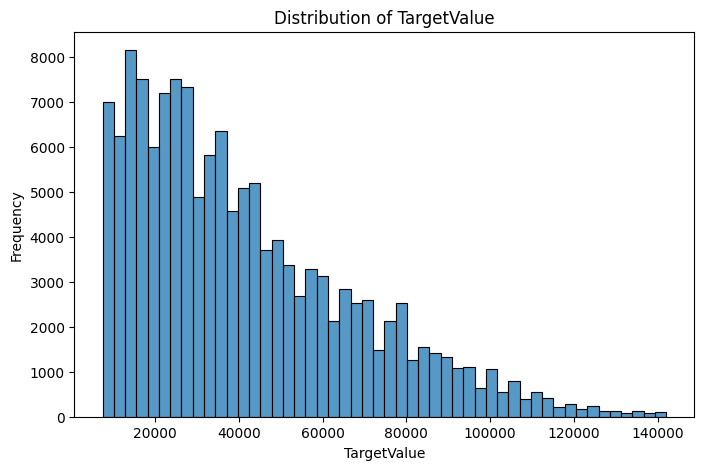

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(train["TargetValue"], bins=50, edgecolor='black')
plt.title("Distribution of TargetValue")
plt.xlabel("TargetValue")
plt.ylabel("Frequency")
plt.show()

- Mean > Median => Distribution is **right-skewed**

In [14]:
train["TargetValue"].describe()

count    138701.000000
mean      41521.874047
std       26361.125948
min        7500.000000
25%       20500.000000
50%       35000.000000
75%       57000.000000
max      142000.000000
Name: TargetValue, dtype: float64

### Distribution after Log Transformation

A log transformation is applied to reduce skewness and improve model learning.

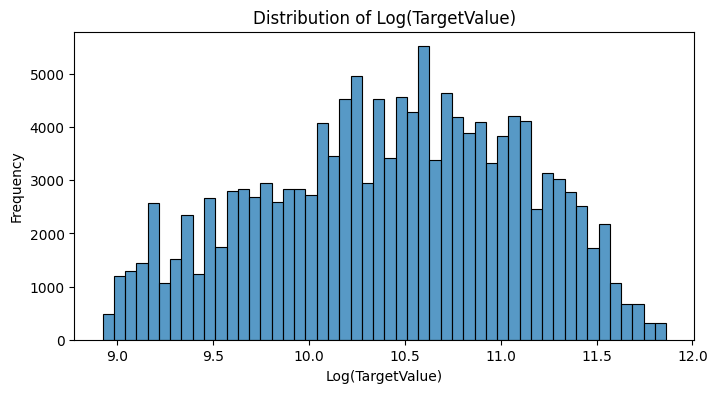

In [15]:
plt.figure(figsize=(8,4))
sns.histplot(np.log1p(train["TargetValue"]), bins=50, edgecolor='black')
plt.title("Distribution of Log(TargetValue)")
plt.xlabel("Log(TargetValue)")
plt.ylabel("Frequency")
plt.show()

**Log transformation** makes the target distribution much more symmetric, making it easier for tree models to learn.

In [16]:
train["TargetValue"].skew()

np.float64(0.9699963984208283)

### 1.4. **Univariate Analysis**

#### 1.4.1. **Numerical Features**

In [17]:
num_cols = train.select_dtypes(exclude='object').columns
print(num_cols)

Index(['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
       'ManufactureYear', 'OperationalHoursMeter'],
      dtype='object')


#### Manufacture Year Analysis

Observations:
- The **ManufactureYear**  contains **14,719 records** with the value **1001**, which is not a realistic manufacturing year for heavy equipment. This suggests that 1001 is likely being used as a **placeholder** for missing or unknown values.
  
- Heavy equipment cannot be manufactured in 1001 AD,as rest of the year starts from 1920,1921..

In [18]:
train['ManufactureYear'].value_counts()

ManufactureYear
1001    14719
2006    10895
2005     9564
1999     7243
2007     7133
        ...  
1949        1
1955        1
2013        1
2014        1
2015        1
Name: count, Length: 68, dtype: int64

#### OperationalHoursMeter Analysis

Observations:
- The OperationalHoursMeter feature is heavily **right-skewed**. While 99% of observations have less than approximately 25,800 operational hours, the maximum recorded value is **1,729,600 hours**, indicating the presence of **extreme outliers or erroneous entries.**

In [19]:
train["OperationalHoursMeter"].describe(percentiles=[0.90,0.95,0.99])

count    8.205800e+04
mean     4.553719e+03
std      2.792204e+04
min      0.000000e+00
50%      1.620000e+03
90%      9.348000e+03
95%      1.303100e+04
99%      2.579601e+04
max      1.729600e+06
Name: OperationalHoursMeter, dtype: float64

### 1.4.2. Categorical Features

In [20]:
cat_cols = train.select_dtypes(include='object').columns
print(cat_cols)

Index(['DataOriginCode', 'VendorPartnerID', 'UtilizationTier',
       'TransactionDate', 'Spec_FullDescriptor', 'Spec_BaseClass',
       'Spec_SubClass', 'Spec_ReleaseSeries', 'Spec_VariantModifier',
       'AssetScaleFactor', 'FunctionalClassification', 'RegionCode',
       'InventoryGroupCategory', 'InventoryGroupDescription',
       'drive_system_config', 'CabinType', 'Forks', 'stabilization_subsystem',
       'extension_arm_layout', 'DrivetrainType', 'engine_intake_type',
       'extension_module_status', 'working_component_width',
       'protective_housing_specs', 'rated_power_output',
       'hydraulic_system_class', 'shock_absorption_interface',
       'piercing_accessories', 'finishing_accessories',
       'actuator_control_logic', 'wheel_dimensions', 'coupling_mechanism',
       'traction_system_type', 'fluid_flow_rate', 'tread_pattern',
       'ground_contact_width', 'max_arm_reach', 'material_retention_design',
       'control_logic_map', 'traction_profile', 'attached_tool_

In [21]:
cat_cols = train.select_dtypes(include='object').columns

train[cat_cols].nunique().sort_values(ascending=False)

TransactionDate               3676
Spec_FullDescriptor           3505
Spec_BaseClass                1249
Spec_SubClass                  147
Spec_VariantModifier           132
Spec_ReleaseSeries             113
FunctionalClassification        65
RegionCode                      53
VendorPartnerID                 31
max_arm_reach                   27
ground_contact_width            18
wheel_dimensions                15
hydraulic_system_class          11
attached_tool_category           9
DrivetrainType                   8
DataOriginCode                   6
working_component_width          6
AssetScaleFactor                 6
InventoryGroupDescription        6
InventoryGroupCategory           6
steering_input_config            5
drive_system_config              4
piercing_accessories             4
UtilizationTier                  3
stabilization_subsystem          3
protective_housing_specs         3
material_retention_design        3
CabinType                        3
traction_profile    

- **Spec_FullDescriptor** & **Spec_BaseClass** exhibit extremely high cardinality, indicating detailed equipment specification information. Special encoding strategies may be required during preprocessing.
- **InventoryGroupDescription** & **InventoryGroupCategory** has same cardinality 6. so they might contain similar information.
- **TransactionDate** has 3676 unique values indicating its **not a categorical column**, its a date feature disguised as text, in preprocessing we can convert it into SaleYear, SaleMonth, SaleDay, SaleWeekday

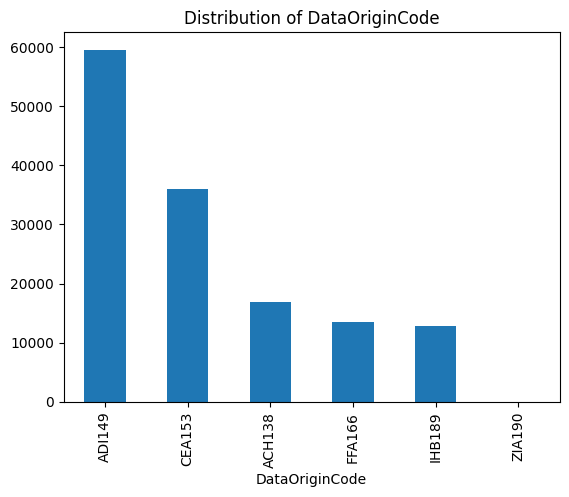

In [22]:
doc = train['DataOriginCode'].value_counts().sort_values(ascending=False).plot(kind='bar')
plt.title("Distribution of DataOriginCode")
plt.show()

Observations on **DataOriginCode** 
- **Massively dominated by ADI149**, which accounts for nearly half of your entire dataset with 59,541 rows.
- **The single-row illusion**, revealing that top-priced **ZIA190** has exactly **one row** and is just a fluke, not a premium category.
- **Strong mid-tier presence**, providing a healthy amount of rows (12k to 36k) for CEA153, ACH138, FFA166, and IHB189.
- **High data imbalance**, showing a drastic drop-off from tens of thousands of records down to just a single transaction.

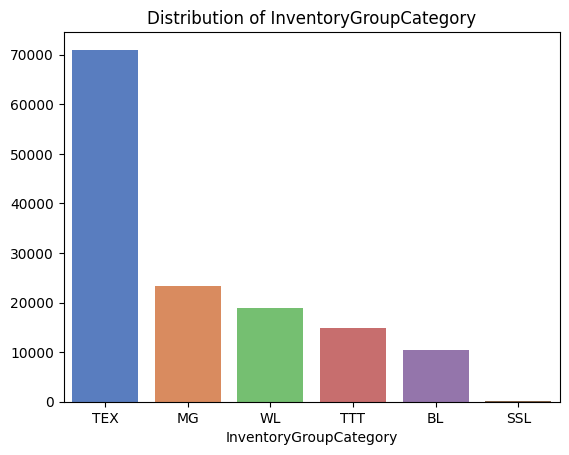

In [23]:
InventoryGroupCategory = train['InventoryGroupCategory'].value_counts()

sns.barplot(x=InventoryGroupCategory.index, y=InventoryGroupCategory.values, hue=InventoryGroupCategory.index, palette='muted')
plt.title("Distribution of InventoryGroupCategory")
plt.show()

Observations on **InventoryGroupCategory** 
- **Heavily dominated by TEX**, which accounts for the vast majority (71,018 rows) of your entire dataset.
- **Robust mid-tier data**, providing plenty of training rows (10k to 23k) for**MG, WL, TTT, and BL**.
- **Near-invisible SSL category**, containing a critically low sample size of just 66 rows.

Observation on **Forks**
- **Massive missing data (NaN)**: Nearly 80% of your dataset (109,382 rows) is completely missing a value for this feature.
- **Hidden "None" overlap**: The category "None or Unspecified" is likely capturing the exact same market reality as the missing NaN values.

Observations on **DrivetrainType**
- **Massive data gaps**, where over 60% of your rows (89,956 rows) are completely missing this tag (NaN).
- **A text typo bug**, where AutoShift and Autoshift are split into two separate categories because of a lowercase letter.

### 1.5. **Bivariate Analysis**

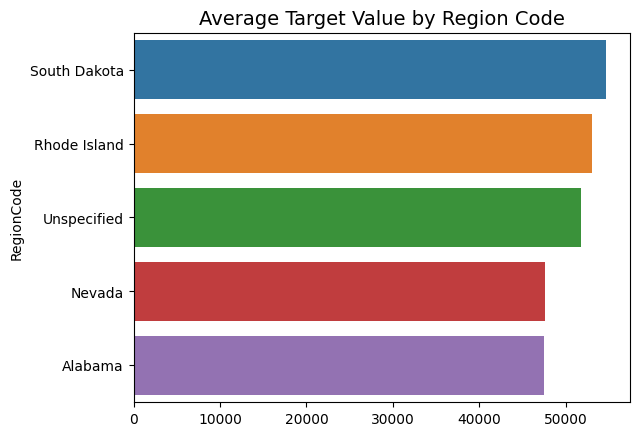

In [24]:
regions = train.groupby('RegionCode')['TargetValue'].mean().sort_values(ascending=False).head()

sns.barplot(x=regions.values, y=regions.index, hue=regions.index)
plt.title("Average Target Value by Region Code", fontsize=14)
plt.show()

Observation: **RegionCode vs TargetValue**

- **South Dakota** has the highest average target value, approaching 55,000.

- Alabama and Nevada share the lowest average target values, both sitting just under 48,000.
  
- The "**Unspecified**" region code ranks third highest, showing a significant amount of uncategorized high-value data.

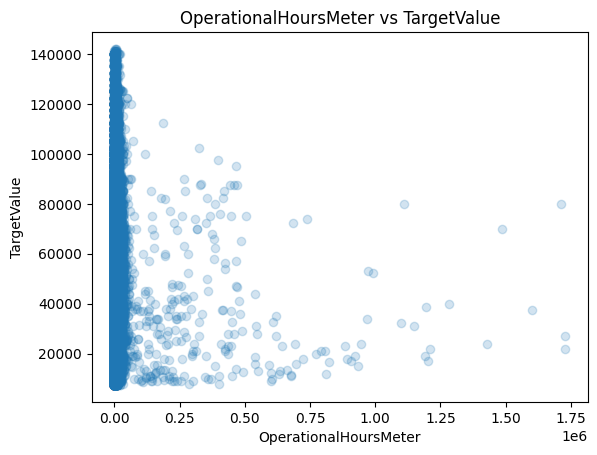

In [25]:
plt.scatter(train["OperationalHoursMeter"],train["TargetValue"],alpha=0.2)

plt.title("OperationalHoursMeter vs TargetValue")
plt.xlabel("OperationalHoursMeter")
plt.ylabel("TargetValue")

plt.show()

Observation: **OperationalHoursMeter vs TargetValue**

- Most machines have **low operational hours**, while only a few have very high usage.
  
- Machines with lower operational hours generally tend to have higher resale values, but the relationship is not very strong.

- The large spread in prices indicates that OperationalHoursMeter alone is **not a strong predictor** and should be used together with other features.

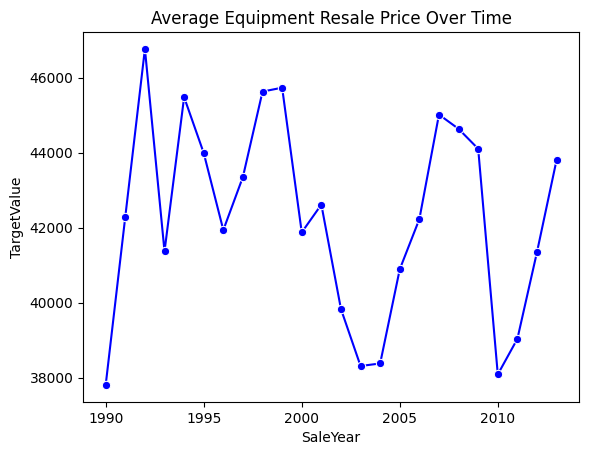

In [26]:
df = train.copy()

df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['SaleYear'] = df['TransactionDate'].dt.year

yearly_price = df.groupby('SaleYear')['TargetValue'].mean().reset_index()
sns.lineplot(data=yearly_price, x='SaleYear', y='TargetValue', color='b', marker='o')
plt.title('Average Equipment Resale Price Over Time')
plt.show()

**Average Equipment Resale Price Over Time (Line Plot)**

- Average resale prices **fluctuate over the years**, indicating that market conditions changed over time.

- SaleYear is a useful predictive feature.

In [27]:
train['UtilizationTier'].value_counts(dropna=False)

UtilizationTier
NaN       88226
Medium    24588
Low       17005
High       8882
Name: count, dtype: int64

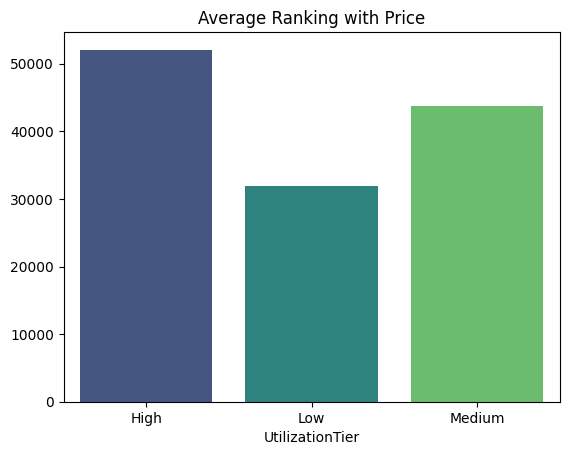

In [28]:
utilization = train.groupby('UtilizationTier')['TargetValue'].mean()

sns.barplot(x=utilization.index, y=utilization.values, hue=utilization.index, palette='viridis')
plt.title('Average Ranking with Price');

Observation: **UtilizationTier vs TargetValue**

- large number of UtilizationTier values are **missing**, but missing values were retained as a separate category.
  
- Machines with **High utilization** have the highest average resale price, while Low utilization machines have the lowest.

- The clear price trend (Low → Medium → High) indicates that UtilizationTier is an important predictive feature.

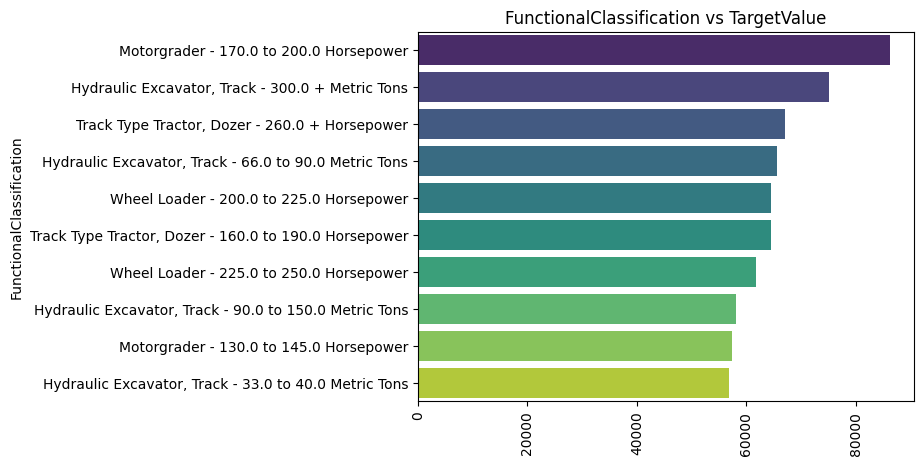

In [29]:
top_fc = train.groupby('FunctionalClassification')['TargetValue'].mean().sort_values(ascending=False).head(10)

sns.barplot(x=top_fc.values, y=top_fc.index, hue=top_fc.index, palette='viridis')
plt.title('FunctionalClassification vs TargetValue')
plt.xticks(rotation=90)
plt.show()

Observation: **FunctionalClassification vs TargetValue**

- TargetValue varies significantly across different FunctionalClassification categories.

- **Larger and more powerful machine** types generally have higher average resale prices.

- This indicates that FunctionalClassification is an important predictive feature for estimating resale value.

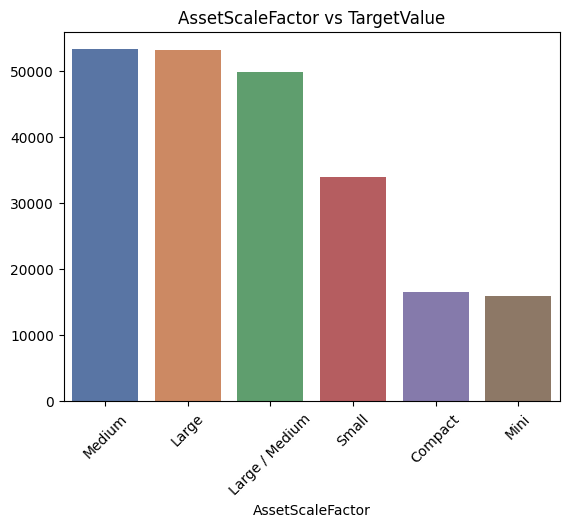

In [30]:
top_fc = train.groupby('AssetScaleFactor')['TargetValue'].mean().sort_values(ascending=False)

sns.barplot(x=top_fc.index, y=top_fc.values, hue=top_fc.index, palette='deep')
plt.title('AssetScaleFactor vs TargetValue')
plt.xticks(rotation=45)
plt.show()

 **Observation: AssetScaleFactor vs TargetValue**

- TargetValue increases with AssetScaleFactor, with larger machines having higher average resale prices.

- **Medium, Large, and Large/Medium machines** show the highest resale values, while Compact and Mini machines have the lowest.

- This indicates that AssetScaleFactor is an important predictive feature for estimating resale value.

### 1.6. Correlation Analysis

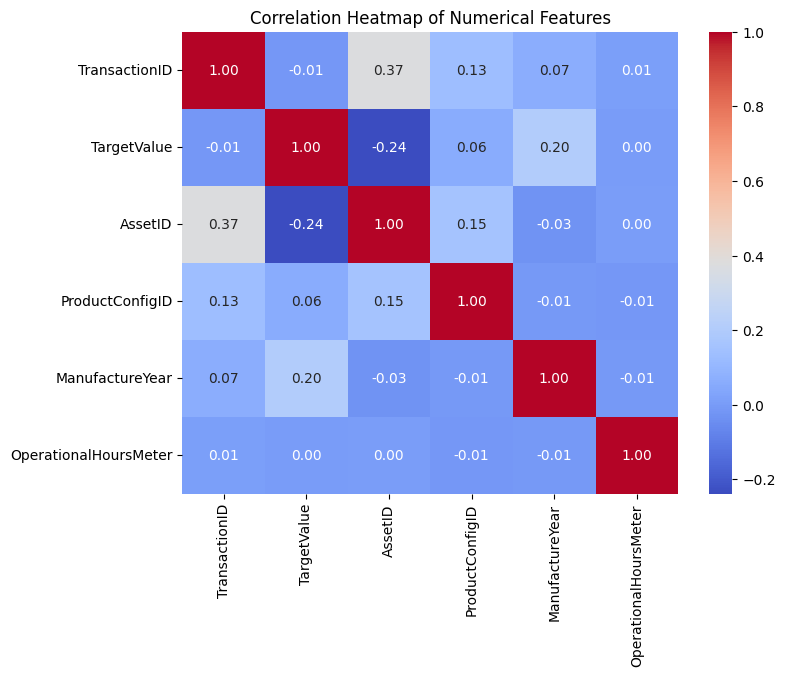

In [31]:
corr_m = train[num_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_m, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

**Correlation Heatmap of Numerical Features**

- Most numerical features show weak correlation with TargetValue, indicating that no single numerical feature strongly explains the resale price.

- **ManufactureYear** has a small positive correlation (0.20) with TargetValue, suggesting newer machines generally have higher resale values.

  
- OperationalHoursMeter has almost no linear correlation with TargetValue, indicating its relationship may be non-linear or depend on other features.


Overall, this suggests that feature engineering and tree-based models are needed to capture complex relationships.

## 2. Data Preprocessing

### 2.1. Removing Extremely Sparse Columns

Columns **traction_system_type, fluid_flow_rate,engine_intake_type, extension_arm_layout**  contained missing values **more than 90%** , leaving only a handful of non-null observations.

Such sparse features are unlikely to provide meaningful predictive information and may introduce noise into the model.

In [32]:
missing_df = pd.DataFrame({
    "Missing_Count": train.isnull().sum(),
    "Missing_Percent": train.isnull().mean()*100
})

missing_df = missing_df.sort_values(
    "Missing_Percent",
    ascending=False
)

missing_df.head(20)

,Missing_Count,Missing_Percent
fluid_flow_rate,138635,99.952416
traction_system_type,138635,99.952416
engine_intake_type,128320,92.515555
extension_arm_layout,128320,92.515555
attached_tool_category,123742,89.214930
steering_input_config,123742,89.214930
differential_type,119829,86.393753
primary_steering_interface,119829,86.393753
finishing_accessories,115296,83.125572
actuator_control_logic,115296,83.125572


In [33]:
drop_cols = ['traction_system_type', 'fluid_flow_rate','engine_intake_type', 'extension_arm_layout' ]

train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [34]:
train.shape # 4 columns dropped

(138701, 46)

### 2.2 Handling Invalid ManufactureYear Values

The value **1001** was identified in **ManufactureYear** during EDA as an **invalid manufacturing year**.

Since 14,719 records contained this value, it was treated as a placeholder for unknown information and replaced with NaN.

In [35]:
(train['ManufactureYear'] == 1001).sum()

np.int64(14719)

In [36]:
train['ManufactureYear'] = train['ManufactureYear'].replace(1001, np.nan)

# for the test also
test['ManufactureYear'] = test['ManufactureYear'].replace(1001, np.nan)

In [37]:
(train['ManufactureYear'] == 1001).sum()

np.int64(0)

In [38]:
train['ManufactureYear'].isnull().sum()

np.int64(14719)

In [39]:
train['DrivetrainType'].unique()

array([nan, 'Powershuttle', 'Standard', 'Powershift',
       'None or Unspecified', 'Hydrostatic', 'Autoshift', 'Direct Drive',
       'AutoShift'], dtype=object)

In [40]:
# Fix category typo
train['DrivetrainType'] = train['DrivetrainType'].replace({'Autoshift':'AutoShift'})

test['DrivetrainType'] = test['DrivetrainType'].replace({'Autoshift':'AutoShift'})

## 3. Feature Engineering

Feature engineering was done to extract additional information from the raw dataset by utilizing temporal information, machine specifications, textual descriptors, and interaction-based features. These engineered features help the model capture patterns that are not directly available in the original variables.

### 3.1. Date-Based Feature Engineering

TransactionDate contains temporal information about equipment sales.

To capture seasonality and market trends, the following features were extracted:

- SaleYear
- SaleMonth
- SaleDay
- SaleWeekday
- SaleQuarter
- SaleWeek

These features help the model capture time trends and seasonality in equipment prices.

In [41]:
train['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
#also for test
test['TransactionDate'] = pd.to_datetime(test['TransactionDate'])

In [42]:
for df in [train, test]:
    df['SaleYear'] = df['TransactionDate'].dt.year
    df['SaleMonth'] = df['TransactionDate'].dt.month
    df['SaleDay'] = df['TransactionDate'].dt.day
    df["SaleWeekday"] = df["TransactionDate"].dt.dayofweek
    df['SaleQuarter'] = df['TransactionDate'].dt.quarter
    df['SaleWeek'] = df['TransactionDate'].dt.isocalendar().week.astype(int)

In [43]:
# droping the transaction date after extraction
train = train.drop(columns=["TransactionDate"], errors="ignore")
test = test.drop(columns=["TransactionDate"], errors="ignore")

### 3.2 Machine Characteristics

- **MachineAge** showed a clear negative relationship with the selling price, indicating **depreciation over time**.
- **CapacityValue** was extracted to represent machine size.

In [44]:
# Motorgrader - 170.0 to 200.0 Horsepower
def capacity(text):
    if pd.isna(text):
        return np.nan

    nums = re.findall(r'\d+\.?\d*', str(text)) #['170.0', '200.0']

    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2   # if 2 numbers are found, compute average

    elif len(nums) == 1:
        return float(nums[0])

    return np.nan

In [45]:
for df in [train,test]:
    df['MachineAge'] = (df['SaleYear'] - df['ManufactureYear'])
    df["CapacityValue"] = df["FunctionalClassification"].apply(capacity)

In [46]:
train['MachineAge'].describe()

count    123982.000000
mean         10.037957
std           7.418629
min          -7.000000
25%           5.000000
50%           8.000000
75%          13.000000
max          92.000000
Name: MachineAge, dtype: float64

In [47]:
train['MachineAge'].isnull().sum()

np.int64(14719)

In [48]:
(train['MachineAge']<0).sum()

np.int64(7)

Since, **MachineAge** has only 7 records less than 0, without any complicated solution, For now I would convert these invalid ages into missing value.

In [49]:
train.loc[train['MachineAge'] < 0,'MachineAge'] = np.nan

#also for test
test.loc[test['MachineAge'] < 0, 'MachineAge'] = np.nan

In [50]:
(train["MachineAge"] < 0).sum()

np.int64(0)

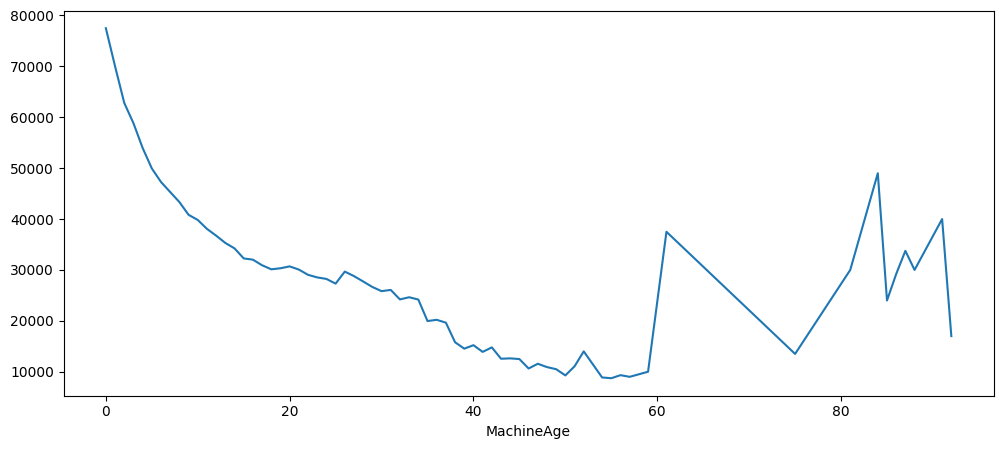

In [51]:
age_mean = (train.groupby("MachineAge")["TargetValue"].mean())

plt.figure(figsize=(12,5))
age_mean.plot()
plt.show()

### 3.3. Specification Features

- Specification-based features capture differences between **machine families** and **configurations**, providing additional information beyond the original categorical variables.

In [52]:
train['Spec_FullDescriptor'].value_counts()

Spec_FullDescriptor
140G          3751
12G           2948
320CL         1556
140HNA        1509
310G          1280
              ... 
EX550BH          1
EX210K5          1
SE240NLC-3       1
DC150BLT         1
R934HDSL         1
Name: count, Length: 3505, dtype: int64

In [53]:
for df in [train, test]: #EX550BH
    df["ModelPrefix"] = (df["Spec_FullDescriptor"].astype(str).str.extract(r'^([A-Za-z]+)')[0]) #EX
    df["ModelNumber"] = (df["Spec_FullDescriptor"].astype(str).str.extract(r'(\d+)')[0])  #550
    df["ModelSuffix"] = (df["Spec_FullDescriptor"].astype(str).str.extract(r'([A-Za-z]+)$')[0]) # BH
    
    df['DescriptorLength'] = df['Spec_FullDescriptor'].fillna('').str.len()
    df["DescriptorWords"] = (df["Spec_FullDescriptor"].fillna("").str.split().str.len())

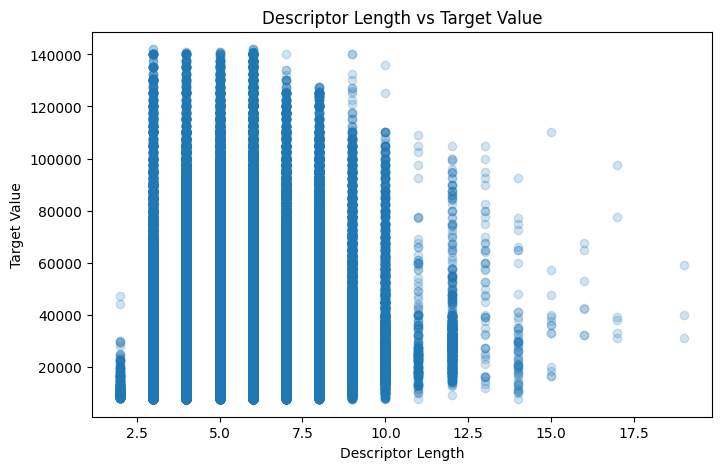

In [54]:
plt.figure(figsize=(8,5))
plt.scatter(train['DescriptorLength'], train['TargetValue'], alpha=0.2)
plt.xlabel('Descriptor Length')
plt.ylabel("Target Value")
plt.title("Descriptor Length vs Target Value")
plt.show()

### 3.4. Binary Indicators

Binary indicators were created to identify the **presence of commonly occurring machine configurations** and optional equipment.

In [55]:
for df in [train, test]:
    #binary indicators
    df["HasLC"] = (df["Spec_FullDescriptor"].astype(str).str.contains("LC", regex=False).astype(int))
    df["HasXL"] = (df["Spec_FullDescriptor"].astype(str).str.contains("XL", regex=False).astype(int))
    df["HasGP"] = (df["Spec_FullDescriptor"].astype(str).str.contains("GP", regex=False).astype(int))
    df["HasBL"] = (df["Spec_FullDescriptor"].astype(str).str.contains("BL", regex=False).astype(int))
    df["HasCL"] = (df["Spec_FullDescriptor"].astype(str).str.contains("CL", regex=False).astype(int))
    df["HasELC"] = (df["Spec_FullDescriptor"].astype(str).str.contains("ELC", regex=False).astype(int))

    df['HasOperationalHours'] = df['OperationalHoursMeter'].notna().astype(int)
    df['HasVariantModifier'] = df['Spec_VariantModifier'].notna().astype(int)

### 3.5. Interaction Features

- Interaction features combine multiple attributes to model relationships that individual features cannot capture independently.
  
- To capture **size-adjusted depreciation** effects, the feature Age_x_ModelNumber was created.

- This allows the model to learn that large machines and small machines may depreciate differently as they age.

In [56]:
for df in [train, test]:
    df["ModelNumberNum"] = pd.to_numeric(df["ModelNumber"],errors="coerce")
    df["Age_x_ModelNumber"] = (df["MachineAge"] * df["ModelNumberNum"])

- **MachineAge** has the strongest negative correlation with TargetValue (-0.35), indicating that older machines generally have lower selling prices.
- **ManufactureYear** (0.28) and **CapacityValue** (0.26) show a moderate positive relationship with the target, suggesting newer and higher-capacity machines tend to sell for more.

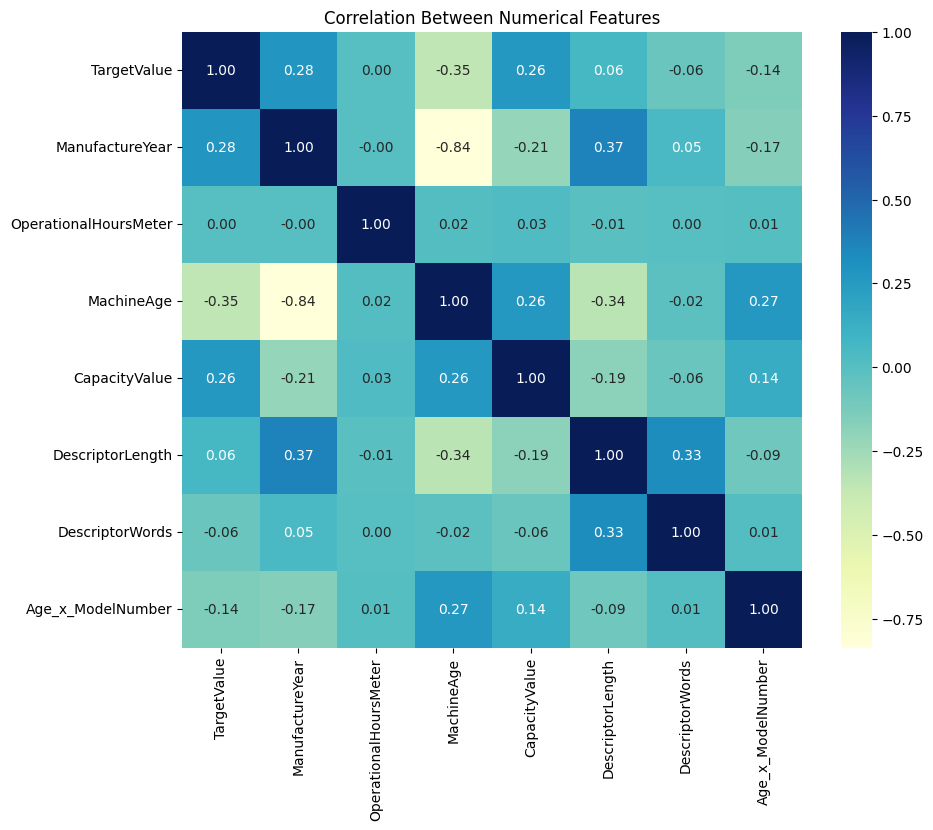

In [57]:
num_features = [
    "TargetValue",
    "ManufactureYear",
    "OperationalHoursMeter",
    "MachineAge",
    "CapacityValue",
    "DescriptorLength",
    "DescriptorWords",
    "Age_x_ModelNumber"
]

plt.figure(figsize=(10,8))
sns.heatmap(train[num_features].corr(),
            annot=True,
            cmap="YlGnBu",
            fmt=".2f")
plt.title("Correlation Between Numerical Features")
plt.show()

## 4. Train/Test Split and Evaluation Metric

- After feature engineering, the dataset was divided into training and validation sets using an **80:20 random split** with a fixed `random_state=42` to ensure reproducibility. Performing the split before imputation and encoding prevents data leakage, as all preprocessing statistics are learned only from the training data and then applied to the validation data.

- Since the competition is evaluated using **Root Mean Squared Logarithmic Error (RMSLE)**, the target variable (`TargetValue`) was transformed using `log1p` before model training. Training on the log-transformed target reduces the influence of extremely large selling prices and aligns the learning objective more closely with the evaluation metric.

- The original target values were retained separately for validation. After prediction, the outputs were converted back to the original price scale using `expm1`, and the final model performance was evaluated using RMSLE.

In [58]:
# Split features and target

X = train.drop("TargetValue", axis=1)
y = train["TargetValue"]

X_tr, X_val, y_tr, y_val = train_test_split(X,y,test_size=0.2,random_state=42)

# Log transformation only for target
y_tr_log = np.log1p(y_tr)
y_val_log = np.log1p(y_val)

## 5. High Cardinality Feature Identification

- Several categorical features contain a large number of unique categories. Applying One-Hot Encoding directly to these features would create thousands of sparse columns, increasing memory usage, computational cost, and the risk of overfitting.

- These features were therefore identified for alternative encoding techniques, such as frequency encoding, while low-cardinality features were handled using One-Hot Encoding.

Examples include:

- Spec_FullDescriptor (3505 categories)
- Spec_BaseClass (1249 categories)
- Spec_SubClass (148 categories)

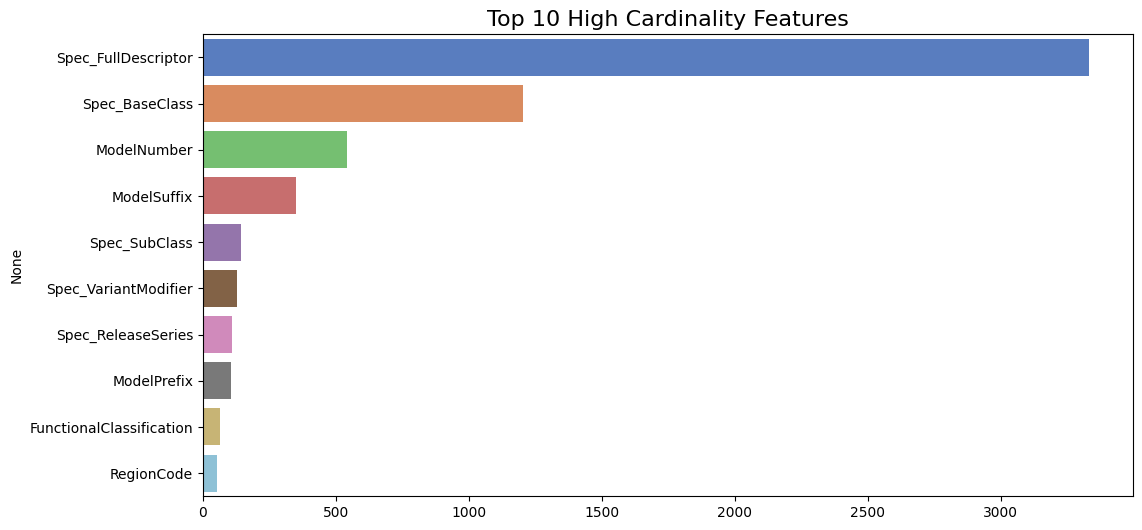

In [59]:
cand_cols = X_tr.select_dtypes(include='object').columns
high_card = X_tr[cand_cols].nunique().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
ax = sns.barplot(x=high_card.values, y=high_card.index, hue=high_card.index, palette='muted', orient='h')
plt.title('Top 10 High Cardinality Features', fontsize=16)
plt.show()

## 6. Data Preprocessing Pipeline

To improve reproducibility, maintain a clean workflow, and prevent data leakage, all preprocessing operations were implemented using **Scikit-learn's Pipeline and ColumnTransformer**.

### 6.1 Feature Groups

In [60]:
median_cols = [
    "ManufactureYear",
    "OperationalHoursMeter",
    "MachineAge",
]

zero_cols = [
    "ModelNumberNum",
    "Age_x_ModelNumber",
    "CapacityValue",
]

freq_cols = [
    "VendorPartnerID",
    "RegionCode",
    "FunctionalClassification",
    "Spec_SubClass",
    "Spec_ReleaseSeries",
    "Spec_VariantModifier",
    "Spec_BaseClass",
    "Spec_FullDescriptor",
    "ModelNumber",
    "ModelSuffix",
    "ModelPrefix",
]

# Remaining categorical columns → One Hot
onehot_cols = [c for c in X_tr.select_dtypes(include="object").columns
    if c not in freq_cols]

### 6.2 Pipeline Definition
- **Numerical Pipeline**: Missing numerical values were imputed using the **median**, which is robust to skewed data and outliers.
  
- **Categorical Pipeline**: Missing categorical values were replaced with "**Missing**", followed by One-Hot Encoding for **low-cardinality features**.

  
- **Frequency Pipeline**: Missing values in high-cardinality categorical features were filled with "**Missing**" before frequency encoding.

  
- **Zero-Imputation Pipeline**: Missing values in engineered numerical features (**ModelNumberNum**, **Age_x_ModelNumber**, and **CapacityValue**) were filled with 0, indicating unavailable extracted information.

In [61]:

num_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

cat_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
])

freq_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing'))
])

zero_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0))
])

### 6.3 ColumnTransformer

- The numerical ,categorical, frequency and Zero pipelines were combined using a **ColumnTransformer**, enabling the appropriate preprocessing steps to be applied to each feature group simultaneously while maintaining a reusable workflow.


In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipe, median_cols),
        ('cat', cat_pipe, onehot_cols),
        ('freq', freq_pipe, freq_cols),
        ('zero', zero_pipe, zero_cols)
], 
    remainder='passthrough',
    verbose_feature_names_out=False)

preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['ManufactureYear', 'OperationalHoursMeter',
                                  'MachineAge']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value='Missing',
                                                                strategy='constant')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=...
                                 ['VendorPartnerID', 'RegionCode',
                                  'FunctionalClassification', 'Spec_SubClass',
                                  'Spec_ReleaseSeries', 'Spec_VariantModifier',
                                  'Spec_BaseClass', 'Spec_FullDescriptor',
                                  'ModelNumber', 'ModelSuffix',
                                  'ModelPrefix']),
                                ('zero',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(fill_value=0,
                                                                strategy='constant'))]),
                                 ['ModelNumberNum', 'Age_x_ModelNumber',
                                  'CapacityValue'])],
                  verbose_feature_names_out=False)

In [63]:
# Fiting on train and transforming on test
X_tr_transformed = preprocessor.fit_transform(X_tr)
X_val_transformed = preprocessor.transform(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 26] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


### 6.4 Conversion to DataFrame
- After preprocessing, the transformed NumPy arrays were converted back into Pandas DataFrames to preserve feature names and simplify further feature engineering and encoding.


In [64]:
# Converting back to DataFrame
X_tr_processed = pd.DataFrame(
    X_tr_transformed,
    columns=preprocessor.get_feature_names_out(),
    index=X_tr.index
)

X_val_processed = pd.DataFrame(
    X_val_transformed,
    columns=preprocessor.get_feature_names_out(),
    index=X_val.index
)

### 6.5 Frequency Encoding

- High-cardinality categorical features were transformed using **Frequency Encoding**, where each category was replaced with its frequency in the training dataset. This reduces dimensionality while preserving category importance.

In [65]:
# Frequency Encoding
for col in freq_cols:
    freq_map = X_tr[col].value_counts()

    X_tr_processed[col+"_freq"] = X_tr_processed[col].map(freq_map).fillna(0)
    X_val_processed[col+'_freq'] = X_val_processed[col].map(freq_map).fillna(0)

In [66]:
# Droping Original High-Cardinality Columns
X_tr_processed.drop(columns=freq_cols, inplace=True)
X_val_processed.drop(columns=freq_cols, inplace=True)

The processed datasets were converted to **float32** to ensure all features have a consistent **numeric data type**, **reduce memory usage**, and improve training efficiency for machine learning models.

In [67]:
X_tr_processed = X_tr_processed.astype(np.float32)
X_val_processed = X_val_processed.astype(np.float32)

### 6.5 Feature Alignment

- The training and test datasets were aligned to ensure both contained the same feature set after encoding, preventing errors during model prediction.


In [68]:
X_tr_processed, X_val_processed = X_tr_processed.align(X_val_processed,join='left',axis=1,fill_value=0)

### 6.6 Feature Name Cleaning
   
- Feature names were cleaned by replacing special characters and spaces with underscores, ensuring compatibility with machine learning libraries such as XGBoost and LightGBM.
- eg;- Item Price ($) --> Item_Price__

In [69]:
def clean_column_names(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^A-Za-z0-9_]+', '_', str(col))
        for col in df.columns
    ]
    return df

X_tr_processed = clean_column_names(X_tr_processed)
X_val_processed = clean_column_names(X_val_processed)

## 7. Model Development

Four models were evaluated:

1. Dummy Regressor (baseline)
2. Random Forest Regressor
3. LightGBM Regressor
4. CatBoost Regressor
5. XGBoost Regressor

Performance was measured using RMSLE. **XGBoost** achieved the best validation performance and was selected as the final model.

In [70]:
def rmsle(y_true, y_pred):
    y_pred = np.maximum(y_pred, 0) #clips neg values to 0
    return np.sqrt(mean_squared_log_error(y_true, y_pred))

### 7.1  Dummy Regressor (Baseline)

A Dummy Regressor predicts the **mean** target value and serves as a baseline.

In [71]:
dummy = DummyRegressor(strategy='mean')

dummy.fit(X_tr_processed, y_tr_log)

dummy_pred_log = dummy.predict(X_val_processed)

dummy_pred = np.expm1(dummy_pred_log)

dummy_rmsle = rmsle(y_val, dummy_pred)
print("Dummy RMSLE:", dummy_rmsle)

Dummy RMSLE: 0.6693714985406403


### 7.2 Random Forest Regressor

Random Forest captures nonlinear relationships and interactions between features while being robust to outliers and overfitting.

In [72]:
rf = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_tr_processed, y_tr_log)

rf_pred_log = rf.predict(X_val_processed)

rf_pred = np.expm1(rf_pred_log)

rf_rmsle = rmsle(y_val, rf_pred)
print("RF RMSLE:", rf_rmsle)

RF RMSLE: 0.22025092194918877


### 7.3 LightGBM Regressor

LightGBM is a gradient boosting algorithm optimized for tabular datasets and large feature spaces.

In [73]:
lgbm = LGBMRegressor(
    n_estimators=3000,
    learning_rate=0.01,
    num_leaves=127,
    max_depth=12,
    min_child_samples=15,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(X_tr_processed, y_tr_log)

lgbm_pred_log = lgbm.predict(X_val_processed)

lgbm_pred = np.expm1(lgbm_pred_log)
y_val_actual = np.expm1(y_val_log)

lgbm_rmsle = rmsle(y_val, lgbm_pred)
print("LightGBM RMSLE:", lgbm_rmsle)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.026679 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3382
[LightGBM] [Info] Number of data points in the train set: 110960, number of used features: 191
[LightGBM] [Info] Start training from score 10.424734
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

### 7.4 CatBoost Regressor

- CatBoost is a gradient boosting algorithm specifically designed to handle **categorical variables** efficiently without requiring one-hot or frequency encoding. Since the dataset contains several high-cardinality categorical features, CatBoost was evaluated as an alternative to XGBoost.

- The model was trained using early stopping to automatically determine the optimal number of boosting iterations while preventing overfitting. Its performance was then compared with the other regression models using the validation RMSLE.

In [74]:
cat = CatBoostRegressor(
    iterations=12000,
    learning_rate=0.03,
    depth=10,
    l2_leaf_reg=3,
    random_strength=2,
    bagging_temperature=0,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

cat.fit(X_tr_processed, y_tr_log, 
        eval_set=(X_val_processed, y_val_log),
        early_stopping_rounds=100
)

# Predict and convert back to original scale
cat_pred_log = cat.predict(X_val_processed)
cat_pred = np.expm1(cat_pred_log)

cat_rmsle = rmsle(y_val, cat_pred)
print("CatBoost RMSLE:", cat_rmsle)

0:	learn: 0.6577502	test: 0.6558703	best: 0.6558703 (0)	total: 118ms	remaining: 23m 35s
200:	learn: 0.2593620	test: 0.2617028	best: 0.2617028 (200)	total: 11.9s	remaining: 11m 38s
400:	learn: 0.2326513	test: 0.2386285	best: 0.2386285 (400)	total: 23.7s	remaining: 11m 24s
600:	learn: 0.2162493	test: 0.2261453	best: 0.2261453 (600)	total: 35.4s	remaining: 11m 12s
800:	learn: 0.2063403	test: 0.2201020	best: 0.2201020 (800)	total: 47.1s	remaining: 10m 58s
1000:	learn: 0.1992489	test: 0.2165403	best: 0.2165403 (1000)	total: 58.8s	remaining: 10m 46s
1200:	learn: 0.1932039	test: 0.2138988	best: 0.2138988 (1200)	total: 1m 10s	remaining: 10m 33s
1400:	learn: 0.1881137	test: 0.2120684	best: 0.2120684 (1400)	total: 1m 22s	remaining: 10m 21s
1600:	learn: 0.1835308	test: 0.2105915	best: 0.2105915 (1600)	total: 1m 33s	remaining: 10m 8s
1800:	learn: 0.1793706	test: 0.2094649	best: 0.2094649 (1800)	total: 1m 45s	remaining: 9m 56s
2000:	learn: 0.1753225	test: 0.2083912	best: 0.2083912 (2000)	total: 1m 

### 7.5 XGBoost Regressor

- XGBoost is a gradient boosting algorithm that builds decision trees sequentially, with each tree correcting the errors of the previous one.
- It was chosen because it handles large tabular datasets, captures complex feature interactions, and includes regularization to reduce overfitting.
- The model also supports early stopping and provides feature importance for interpretation.
- After hyperparameter tuning, XGBoost achieved the lowest validation RMSLE among all evaluated models and was selected as the primary model for the final ensemble.

In [75]:
xgb = XGBRegressor(
    n_estimators=11084,
    learning_rate=0.008,
    max_depth=10,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42
)

xgb.fit(X_tr_processed, y_tr_log)
xgb_pred_log = xgb.predict(X_val_processed)

# Converting back to original
xgb_pred = np.expm1(xgb_pred_log)

xgb_rmsle = rmsle(y_val, xgb_pred)
print("XGBoost RMSLE:", xgb_rmsle)

XGBoost RMSLE: 0.19645956044622823


In [76]:
blend_pred = (
    0.7 * xgb_pred +
    0.3 * cat_pred
)

blend_rmsle = rmsle(y_val, blend_pred)
print("Blend RMSLE:", blend_rmsle)

Blend RMSLE: 0.19583447142979754


## 8. Model Comparison

- To evaluate different machine learning approaches, multiple regression models were trained and compared using the **Root Mean Squared Logarithmic Error (RMSLE)** on the validation set.

- The comparison shows that **XGBoost** achieved the lowest RMSLE among all evaluated models, indicating better predictive performance. Therefore, XGBoost was selected as the final model for generating competition submissions.

In [77]:
results = pd.DataFrame({
    "Model": ["Dummy", "Random Forest", "LightGBM","CatBoost", "XGBoost"],
    "RMSLE": [dummy_rmsle, rf_rmsle, lgbm_rmsle, cat_rmsle, xgb_rmsle]
})
results.sort_values("RMSLE")

,Model,RMSLE
4,XGBoost,0.196460
3,CatBoost,0.199220
2,LightGBM,0.206201
1,Random Forest,0.220251
0,Dummy,0.669371


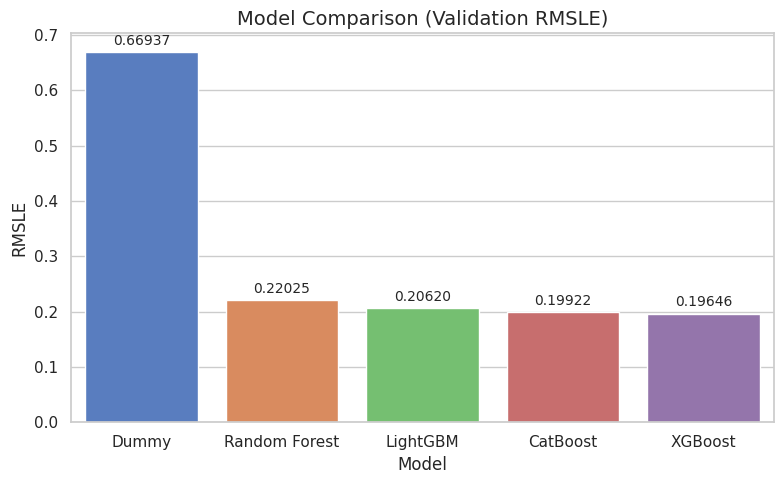

In [78]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.barplot(x="Model", y="RMSLE", data=results, palette="muted",hue="Model",legend=False)
plt.title("Model Comparison (Validation RMSLE)", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("RMSLE", fontsize=12)

for container in ax.containers:
    ax.bar_label(container, fmt="%.5f", padding=3, fontsize=10)

plt.tight_layout()
plt.show()


## 9. Hyperparameter Optimization of XGBoost


### Experiment: Determining the Optimal Number of Trees using Early Stopping

- One of the most important hyperparameters in XGBoost is **n_estimators**, which specifies the number of boosting trees. Choosing too few trees may lead to **underfitting**, while too many trees increase training time and may eventually lead to overfitting.

- Instead of selecting this value manually, an **Early Stopping** experiment was performed. During training, the validation RMSE was monitored after each boosting iteration. Training continued as long as the validation score improved and stopped once no further improvement was observed for a predefined number of rounds.

- This approach allows the model to automatically identify the optimal number of trees while preventing unnecessary training.

### Experimental Results

| Experiment | Learning Rate | Trees | Max Depth | Min Child Weight | Subsample | Colsample | Validation RMSLE |
|-----------|--------------:|------:|----------:|-----------------:|-----------:|-----------:|-----------------:|
| 1 | 0.015 | 3542 | 12 | 4 | 0.85 | 0.85 | 0.197901 |
| 2 | 0.012 | 4064 | 12 | 4 | 0.85 | 0.85 | 0.197654 |
| 3 | 0.010 | 5364 | 12 | 4 | 0.85 | 0.85 | 0.197572 |
| 4 | 0.008 | 6082 | 12 | 4 | 0.85 | 0.85 | 0.197307 |
| 5 | 0.008 | 7997 | 11 | 4 | 0.85 | 0.85 | 0.196780 |
| 6 | 0.008 | 9007 | 11 | 4 | 0.85 | 0.85 | 0.196727 |
| 7 | 0.008 | 9007 | 10 | 4 | 0.85 | 0.85 | 0.196684 |
| **Final** | **0.008** | **11084** | **10** | **5** | **0.85** | **0.85** | **0.196459** |


### Observation

- The initial model used **2000 trees**, which did not fully converge.
- Early stopping showed that the validation error continued to decrease even after several thousand boosting rounds.
- The best validation performance was achieved with **11,084 boosting trees**.
- Validation RMSLE improved from **0.198425** to **0.196459**.

### Conclusion

The hyperparameters identified through this experiment were used for the final XGBoost model. Early stopping provided a systematic way to determine the optimal model complexity, resulting in improved predictive performance while avoiding arbitrary selection of the number of boosting trees.

In [79]:

xgb = XGBRegressor(
    n_estimators=12000,
    learning_rate=0.008,
    max_depth=10,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    eval_metric="rmse",
    early_stopping_rounds=200
)

xgb.fit(X_tr_processed,
    y_tr_log,
    eval_set=[(X_val_processed, y_val_log)],
    verbose=100
)

xgb_pred_log = xgb.predict(X_val_processed)

xgb_pred = np.expm1(xgb_pred_log)

xgb_rmsle = rmsle(y_val, xgb_pred)

print("XGBoost RMSLE:", xgb_rmsle)
print("Best iteration:", xgb.best_iteration)
print("Best validation RMSE:", xgb.best_score)

[0]	validation_0-rmse:0.66520
[100]	validation_0-rmse:0.39349
[200]	validation_0-rmse:0.29108
[300]	validation_0-rmse:0.25173
[400]	validation_0-rmse:0.23419
[500]	validation_0-rmse:0.22485
[600]	validation_0-rmse:0.21913
[700]	validation_0-rmse:0.21567
[800]	validation_0-rmse:0.21334
[900]	validation_0-rmse:0.21165
[1000]	validation_0-rmse:0.21033
[1100]	validation_0-rmse:0.20923
[1200]	validation_0-rmse:0.20821
[1300]	validation_0-rmse:0.20732
[1400]	validation_0-rmse:0.20659
[1500]	validation_0-rmse:0.20600
[1600]	validation_0-rmse:0.20540
[1700]	validation_0-rmse:0.20486
[1800]	validation_0-rmse:0.20437
[1900]	validation_0-rmse:0.20389
[2000]	validation_0-rmse:0.20347
[2100]	validation_0-rmse:0.20310
[2200]	validation_0-rmse:0.20276
[2300]	validation_0-rmse:0.20244
[2400]	validation_0-rmse:0.20214
[2500]	validation_0-rmse:0.20187
[2600]	validation_0-rmse:0.20158
[2700]	validation_0-rmse:0.20133
[2800]	validation_0-rmse:0.20112
[2900]	validation_0-rmse:0.20088
[3000]	validation_0-rm

## 10. Feature Importance Analysis

- After training the final XGBoost model, feature importance was examined to understand which variables contributed most to the prediction of machinery resale prices.

- The model identified several highly influential features. Missing value indicators such as **working_component_width_missing**, **max_arm_reach_Missing**, and **hydraulic_system_class_Missing** received the highest importance scores, indicating that the absence of information itself contains predictive value.

- Machine specification features including **AssetScaleFactor**, **InventoryGroupDescription**, **CabinType**, **CapacityValue**, and **MachineAge** were also among the most important predictors. This confirms the observations made during Exploratory Data Analysis that machine size, age, and configuration strongly influence resale value.

Overall, the feature importance analysis demonstrates that the engineered features successfully captured meaningful information and that the model relied primarily on machine specifications, equipment size, age, and missing-value patterns when estimating selling prices.

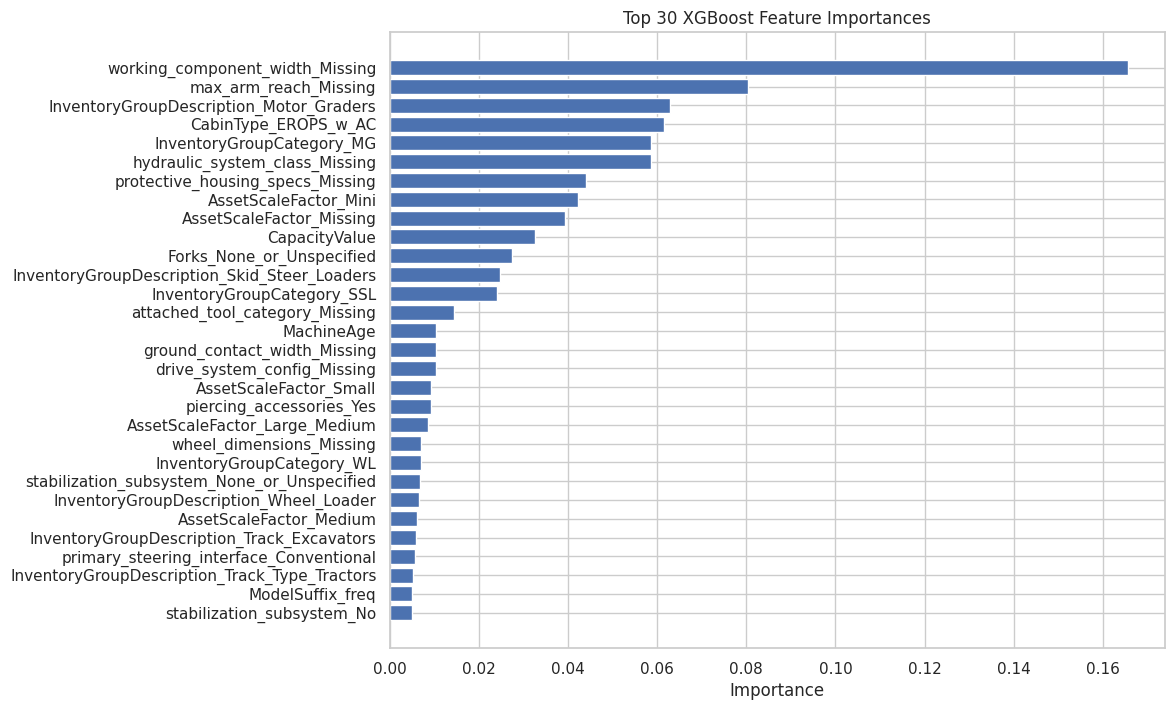

In [80]:
importance = pd.DataFrame({
    "Feature": X_tr_processed.columns,
    "Importance": xgb.feature_importances_
}).sort_values("Importance", ascending=False)

top30 = importance.head(30)

plt.figure(figsize=(10, 8))
plt.barh(top30["Feature"], top30["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 30 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.show()


## 11. Final Model (Ensemble) and Submission

- The `preprocess()` function applies all preprocessing steps to the complete training and test datasets, ensuring consistent feature engineering and encoding before training the final ensemble model.

- The best-performing individual models were **XGBoost** and **CatBoost**. To further improve generalization, an ensemble approach was adopted by combining their predictions using a weighted average.

- Observation:

    - The final model combines **70% XGBoost** and **30% CatBoost** predictions.
    - This ensemble leverages the strengths of both boosting algorithms, resulting in better generalization and reduced prediction error.
    - The ensemble improved the Kaggle Public Score from**0.19160 to 0.19130**, making it the final model selected for submission.

In [81]:
def preprocess(train_df, test_df):
    
    train_df = train_df.copy()
    test_df = test_df.copy()

    for df in [train_df, test_df]:
        # Drop columns with more than 90% missing values
        drop_cols = ['traction_system_type', 'fluid_flow_rate','engine_intake_type', 'extension_arm_layout' ]
        df.drop(columns=drop_cols, inplace=True)

        # replacing invalid ManufactureYear values with NaN
        df['ManufactureYear'] = df['ManufactureYear'].replace(1001, np.nan)

        # Feature Enginnering
        #Date Features
        df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
        df['SaleYear'] = df['TransactionDate'].dt.year
        df['SaleMonth'] = df['TransactionDate'].dt.month
        df['SaleDay'] = df['TransactionDate'].dt.day
        df['SaleWeekday'] = df['TransactionDate'].dt.dayofweek #Monday=0, Sunday=6
        df['SaleQuarter'] = df['TransactionDate'].dt.quarter # 1,2,3,4
        df['SaleWeek'] = df['TransactionDate'].dt.isocalendar().week.astype(int) # 1-52
        # drop TransactionDate
        df.drop(columns=['TransactionDate'], inplace=True)

        #Machine Age
        df['MachineAge'] = (df['SaleYear'] - df['ManufactureYear']) # it calculates the age of the machine. This feature can be useful for predicting resale value, as older machines may have lower resale prices.
        # Replace negative ages with NaN
        df.loc[df['MachineAge'] < 0, 'MachineAge'] = np.nan
        # Fix category typo
        df['DrivetrainType'] = df['DrivetrainType'].replace({'Autoshift':'AutoShift'})

        # Model Features
        df['ModelNumber'] = df['Spec_FullDescriptor'].astype(str).str.extract(r'(\d+)')[0] #it extracts the first sequence of digits from the 'Spec_FullDescriptor' column, which is assumed to represent the model number of the equipment. This feature can be useful for predicting resale value, as different models may have different resale prices.
        df['ModelSuffix'] = df['Spec_FullDescriptor'].astype(str).str.extract(r'([A-Za-z]+)$')[0] #it extracts the last sequence of letters from the 'Spec_FullDescriptor' column, which is assumed to represent the model suffix of the equipment
        df['ModelPrefix'] = df['Spec_FullDescriptor'].astype(str).str.extract(r'^([A-Za-z]+)')[0] #it extracts the first sequence of letters from the 'Spec_FullDescriptor' column, which is assumed to represent the model prefix of the equipment. This feature can be useful for predicting resale value, as different model prefixes may have different resale prices.

        # Binary Indicators for Model Features
        df['HasLC'] = df['Spec_FullDescriptor'].astype(str).str.contains('LC', regex=False).astype(int) # it indicates whether the 'Spec_FullDescriptor' column contains the word 'LC'. This feature can be useful for predicting resale value, as different model features may have different resale prices.
        df['HasXL'] = df['Spec_FullDescriptor'].astype(str).str.contains('XL', regex=False).astype(int)
        df['HasGP'] = df['Spec_FullDescriptor'].astype(str).str.contains('GP', regex=False).astype(int)
        df['HasBL'] = df['Spec_FullDescriptor'].astype(str).str.contains('BL', regex=False).astype(int)
        df['HasCL'] = df['Spec_FullDescriptor'].astype(str).str.contains('CL', regex=False).astype(int)
        df['HasELC'] = df['Spec_FullDescriptor'].astype(str).str.contains('ELC', regex=False).astype(int)

        df['ModelNumberNum'] = pd.to_numeric(df['ModelNumber'], errors='coerce') # it converts the 'ModelNumber' column to numeric values, with any non-numeric values being replaced with NaN. This feature can be useful for predicting resale value, as different model numbers may have different resale prices.

        # Interaction Feature
        df['Age_x_ModelNumber'] = df['MachineAge'] * df['ModelNumberNum'] # it creates a new feature that is the product of the 'MachineAge' and 'ModelNumberNum' columns. This feature can be useful for predicting resale value, as the interaction between machine age and model number may have an impact on resale prices.

        # Capacity Feature
        df['CapacityValue'] = df['FunctionalClassification'].apply(capacity) # it applies the 'capacity' function to the 'FunctionalClassification' column, which extracts the capacity value from the text. This feature can be useful for predicting resale value, as different capacity values may have different resale prices.
        # Descriptor Features
        df['DescriptorLength'] = df['Spec_FullDescriptor'].fillna('').str.len() # it calculates the length of the 'Spec_FullDescriptor' column, filling any missing values with an empty string. This feature can be useful for predicting resale value, as longer descriptors may indicate more features or specifications, which could impact resale prices.
        df['DescriptorWords'] = df['Spec_FullDescriptor'].fillna('').str.split().str.len() # it calculates the number of words in the 'Spec_FullDescriptor' column, filling any missing values with an empty string. This feature can be useful for predicting resale value, as more words in the descriptor may indicate more features or specifications, which could impact resale prices.
        # Missingness Features
        df['HasOperationalHours'] = df['OperationalHoursMeter'].notna().astype(int) # if the 'OperationalHoursMeter' column is not null, it assigns a value of 1, otherwise 0. This feature can be useful for predicting resale value, as machines with operational hours may have different resale prices compared to those without.
        df['HasVariantModifier'] = df['Spec_VariantModifier'].notna().astype(int)

    # Data Preprocessing Pipeline

    median_cols = [
        "ManufactureYear",
        "OperationalHoursMeter",
        "MachineAge"
    ]

    zero_cols = [
        "ModelNumberNum",
        "Age_x_ModelNumber",
        "CapacityValue"
    ]

    freq_cols = [    
        "VendorPartnerID",
        "RegionCode",
        "FunctionalClassification",
        "Spec_SubClass",
        "Spec_ReleaseSeries",
        "Spec_VariantModifier",
        "Spec_BaseClass",
        "Spec_FullDescriptor",
        "ModelNumber",
        "ModelSuffix",
        "ModelPrefix",
    ]

    onehot_cols = [c for c in train_df.select_dtypes(include="object").columns if c not in freq_cols]

    # pipelines
    num_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median'))
    ])
    cat_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'))
    ])

    freq_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing'))
    ])

    zero_pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value=0))
    ])
    
    # Create preprocessor
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_pipe, median_cols),
            ('cat', cat_pipe, onehot_cols),
            ('freq', freq_pipe, freq_cols),
            ('zero', zero_pipe, zero_cols)
        ],
        remainder='passthrough',
        verbose_feature_names_out=False
    )

    # Fiting on train and transforming on test
    train_transformed = preprocessor.fit_transform(train_df)
    test_transformed = preprocessor.transform(test_df)

    # Conversion to Dataframe
    one_hot_features = preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(onehot_cols)
    
    train_processed = pd.DataFrame(
        train_transformed,
        columns=preprocessor.get_feature_names_out(),
        index=train_df.index
    )
    test_processed = pd.DataFrame(
        test_transformed,
        columns=preprocessor.get_feature_names_out(),
        index=test_df.index
    )

    # Frequnecy Encoding
    for col in freq_cols:
        freq_map = train_processed[col].value_counts()
        train_processed[col + '_freq'] = train_processed[col].map(freq_map).fillna(0)
        test_processed[col + '_freq'] = test_processed[col].map(freq_map).fillna(0)

    # Droping Original High-Cardinality Columns
    train_processed.drop(columns=freq_cols, inplace=True)
    test_processed.drop(columns=freq_cols, inplace=True)

    train_processed = train_processed.astype(np.float32)
    test_processed = test_processed.astype(np.float32)

    # aligning the columns of the training and test sets to ensure they have the same features
    train_processed, test_processed = train_processed.align(test_processed, join='left', axis=1, fill_value=0)

    # Feature Name Cleaning
    train_processed.columns = [
        re.sub(r"[^A-Za-z0-9_]+", "_", str(col))
        for col in train_processed.columns
    ]

    test_processed.columns = [
        re.sub(r"[^A-Za-z0-9_]+", "_", str(col))
        for col in test_processed.columns
    ]

    return train_processed, test_processed

train_final_processed, test_final_processed = preprocess(
    train_raw.drop(columns="TargetValue"),
    test_raw
)

In [82]:
X_final = train_final_processed
# Target (from the original training dataframe)
y_final = np.log1p(train_raw["TargetValue"])

# Final XGBoost training
xgb_final = XGBRegressor(
    n_estimators=11084,
    learning_rate=0.008,
    max_depth=10,
    min_child_weight=5,
    subsample=0.85,
    colsample_bytree=0.85,
    random_state=42,
    eval_metric="rmse"
)

# Final CatBoost training
cat_final = CatBoostRegressor(
    iterations=12000,
    learning_rate=0.03,
    depth=10,
    l2_leaf_reg=3,
    random_strength=2,
    bagging_temperature=0,
    loss_function="RMSE",
    random_seed=42,
    verbose=200
)

# #Train on full data using log target
xgb_final.fit(X_final, y_final)
cat_final.fit(X_final,y_final)

# Predicting on test and converting it back from log scale
xgb_test = np.expm1(xgb_final.predict(test_final_processed[X_final.columns]))
cat_test = np.expm1(cat_final.predict(test_final_processed[X_final.columns]))

# Weighted Ensemble
final_pred = (0.7*xgb_test + 0.3*cat_test)

# Preventing negative prices
final_pred = np.clip(final_pred, 0, None)

0:	learn: 0.6575404	total: 71.2ms	remaining: 14m 14s
200:	learn: 0.2579074	total: 13.9s	remaining: 13m 36s
400:	learn: 0.2315768	total: 27.7s	remaining: 13m 22s
600:	learn: 0.2158924	total: 41.6s	remaining: 13m 9s
800:	learn: 0.2066357	total: 55.5s	remaining: 12m 55s
1000:	learn: 0.1999751	total: 1m 9s	remaining: 12m 43s
1200:	learn: 0.1943800	total: 1m 23s	remaining: 12m 29s
1400:	learn: 0.1894711	total: 1m 37s	remaining: 12m 16s
1600:	learn: 0.1852142	total: 1m 51s	remaining: 12m 2s
1800:	learn: 0.1814406	total: 2m 5s	remaining: 11m 49s
2000:	learn: 0.1780258	total: 2m 19s	remaining: 11m 35s
2200:	learn: 0.1747040	total: 2m 33s	remaining: 11m 22s
2400:	learn: 0.1716954	total: 2m 47s	remaining: 11m 8s
2600:	learn: 0.1688393	total: 3m 1s	remaining: 10m 54s
2800:	learn: 0.1662372	total: 3m 15s	remaining: 10m 40s
3000:	learn: 0.1637355	total: 3m 28s	remaining: 10m 26s
3200:	learn: 0.1612337	total: 3m 42s	remaining: 10m 12s
3400:	learn: 0.1586835	total: 3m 56s	remaining: 9m 58s
3600:	lear

In [83]:
submission = pd.DataFrame({
    "TransactionID": test["TransactionID"].astype("int32"),
    "TargetValue": final_pred
})

submission.to_csv("submission.csv", index=False)
print(submission.shape)
submission.head()

(15000, 2)


,TransactionID,TargetValue
0,1139307,64146.805305
1,1139419,71830.696224
2,1139482,33907.266513
3,1139522,20571.154602
4,1139684,12917.551088


# Milestone 1:

In [84]:
# ms1 = train.copy()

### Dataset Dimensions

The first step in Exploratory Data Analysis (EDA) is to understand the size of the dataset.

We check the number of rows and columns in both the training and testing datasets to understand how much data is available for model training and prediction.

In [85]:
# ms1.shape[0], ms1.shape[0]

### Target Variable Identification

The training dataset contains one additional column compared to the testing dataset.

This extra column represents the value that the machine learning model must learn to predict.

In [86]:
# set(train.columns) - set(test.columns)

### Numerical Features

Machine learning models treat numerical and categorical features differently.

We first identify all columns stored as integer (`int64`) or floating-point (`float64`) values.

In [87]:
# num_cols = ms1.select_dtypes(include=['int64','float64']).columns
# print(len(num_cols))

<!-- ### Missing Value Analysis -->

Features with an extremely high percentage of missing values contain very little useful information. Identifying these columns helps decide whether they should be removed or handled differently during preprocessing.

In [88]:
# missing_pct = ms1.isnull().mean()*100

# missing_pct[missing_pct > 90]

### Missing Operational Hours

OperationalHoursMeter represents the total runtime of a machine. Measuring its missing percentage helps determine the amount of information lost and guides the imputation strategy.

In [89]:
# ms1['OperationalHoursMeter'].isnull().mean()*100

### Target Value Distribution

The median provides a robust measure of the typical machine price because it is less affected by extreme values than the mean.

In [90]:
# ms1['TargetValue'].median()

### Manufacture Year Analysis

Before creating age-related features, it is important to inspect the distribution of manufacture years and identify invalid placeholder values used during data collection.

In [91]:
# ms1['ManufactureYear'].value_counts()

### Transaction Timeline

Understanding the time span of the dataset provides context about the period over which machinery transactions were recorded.

In [92]:
# ms1['TransactionDate'] = pd.to_datetime(train['TransactionDate'])
# ms1['TransactionDate'].min()

### High Cardinality Analysis

Categorical features with many unique values require special encoding techniques. Measuring the number of unique categories helps determine whether One-Hot Encoding or Target Encoding is more appropriate.

In [93]:
# ms1['Spec_BaseClass'].nunique()

### Regional Distribution

Analyzing transaction frequency across regions helps identify where most machinery sales occur and provides useful business insights.

- **Florida** region accounts for the highest volume of machinery transactions (RegionCode) in this dataset

In [94]:
# ms1['RegionCode'].value_counts().head()

### Regional Pricing

Calculating the average selling price within a region helps identify differences in machinery valuation across geographical markets.

In [95]:
# ms1.groupby('RegionCode')['TargetValue'].mean().sort_values(ascending=False)

### Asset Utilization

The UtilizationTier describes how heavily a machine was used. Examining its frequency distribution helps understand the composition of the dataset.

In [96]:
# ms1['UtilizationTier'].value_counts()

### Operational Hours vs Target Value

Pearson correlation measures the strength and direction of the linear relationship between machine usage and selling price.

In [97]:
# corr_m = ms1.corr(method='pearson', numeric_only=True)

# sns.heatmap(corr_m,cmap='YlGnBu', annot=True)

### Functional Classification Distribution

Identifying the most common machinery type provides insight into which equipment categories dominate the marketplace and may influence model learning.

In [98]:
# ms1['FunctionalClassification'].mode()

# Milestone 2:

In [99]:
# ms2_train = train.copy()
# ms2_test = test.copy()

### Section 1: Feature Engineering

Additional features were created to extract useful information from the raw dataset.

The objective was to capture temporal information, machine age, descriptor complexity, and the presence of operational or variant information that may influence the target variable.

### Time-Based Features

TransactionDate contains useful temporal information.

The following features were extracted:

- TransactionYear
- TransactionQuarter
- AssetAge

AssetAge was created by subtracting ManufactureYear from TransactionYear and represents the age of the asset at the time of sale.

In [100]:
# ms2_train['TransactionDate'] = pd.to_datetime(ms2_train['TransactionDate'])
# #also for test
# ms2_test['TransactionDate'] = pd.to_datetime(ms2_test['TransactionDate'])

In [101]:
# for df in [ms2_train, ms2_test]:
#     df['TransactionYear'] = df['TransactionDate'].dt.year
#     df['TransactionQuarter'] = df['TransactionDate'].dt.quarter
#     df['AssetAge'] = df['TransactionYear'] - df['ManufactureYear']

In [102]:
# ms2_train['AssetAge'].mode()[0]

In [103]:
# ms2_train.groupby('TransactionQuarter')['TargetValue'].mean()

In [104]:
# mean = ms2_train['ManufactureYear'].mean()
# print(round(mean, 2))

### Descriptor-Based Features

Spec_FullDescriptor contains descriptive information about the machine.

DescriptorLength was created to measure the complexity and amount of information contained within the descriptor.

In [105]:
# for df in [ms2_train, ms2_test]:
    # df['DescriptorLength'] = df['Spec_FullDescriptor'].fillna('').str.len()

In [106]:
# ms2_train['DescriptorLength'].max()

### Availability Indicator Features

Missing values often contain useful information.

Binary indicators were created to capture whether operational hours and variant information were available for a particular asset.

In [107]:
# for df in [ms2_train, ms2_test]:
#     df['HasOperationalHours'] = df['OperationalHoursMeter'].notna().astype(int)
#     df['HasVariantModifier'] = df['Spec_VariantModifier'].notna().astype(int)

In [108]:
# ms2_train['HasOperationalHours'].value_counts()

In [109]:
# ms2_train['HasVariantModifier'].value_counts(normalize=True)*100

### Section 2: One-Hot Encoding

Categorical features cannot be directly used by most machine learning algorithms.

One-Hot Encoding was applied to RegionCode, CabinType, and UtilizationTier using drop_first=True to avoid multicollinearity.

In [110]:
# ms2_train = train.copy()

In [111]:
# ms2_train = pd.get_dummies(
#     ms2_train,
#     columns=['RegionCode','CabinType','UtilizationTier'],
#     drop_first=True
# )

In [112]:
# ms2_train.shape[1]

### Section 3: Correlation Analysis

A correlation matrix was computed using numerical features to identify variables most strongly associated with TargetValue.

This helps understand which predictors may be useful for modeling.

In [113]:
# numeric_cols = ms2_train.select_dtypes(include=np.number)
# corr_matrix = numeric_cols.corr()
# corr_matrix['TargetValue'].abs().sort_values(ascending=False)

### Section 4: Feature Scaling

Missing values were imputed using the mean value of each feature.

StandardScaler was then applied to numerical variables to standardize their distributions and ensure comparable scales.

In [114]:
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler

# scale_cols = ['ManufactureYear','OperationalHoursMeter','AssetAge']

# #Simple Imputer
# si = SimpleImputer(strategy='mean')
# ms2_train[scale_cols] = si.fit_transform(ms2_train[scale_cols])

# #SatndardScaler
# ss = StandardScaler()
# ms2_train[scale_cols] = ss.fit_transform(ms2_train[scale_cols])

### Section 5: Train/Test Split

The processed dataset was divided into training and validation subsets.

A test size of 20% and random state of 42 were used to ensure reproducible model evaluation.

In [115]:
# X = ms2_train[['ManufactureYear','AssetAge']]
# y = ms2_train['TargetValue']

In [116]:
# from sklearn.model_selection import train_test_split

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Section 6: Linear Regression Model

A Linear Regression model was trained using:

- ManufactureYear
- AssetAge

The model was evaluated on the validation dataset using the R² metric to assess its explanatory power.

In [117]:
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score

# lr = LinearRegression()
# lr.fit(X_train, y_train)
# y_pred = lr.predict(X_test)

# r2 = r2_score(y_test, y_pred)
# r2

# Milestone 3:

In [118]:
# ms3 = ms2_train.copy()

### Datetime Extraction

The TransactionDate column is converted into datetime format, and the SaleYear is extracted.

The mode of SaleYear is then calculated.

In [119]:
# ms3['SaleYear'] = pd.to_datetime(ms3['TransactionDate']).dt.year
# ms3['SaleYear'].mode()

### Imputing Missing Categorical Data

Missing values in CabinType are replaced with the string "Missing".

The total number of rows containing the value "Missing" is then counted.

In [120]:
# ms3['CabinType'] = ms3['CabinType'].fillna('Missing')
# missing_count = (ms3['CabinType'] == 'Missing').sum()
# missing_count

### Calculating Asset Age

Invalid manufacture years (1000 and 1001) are replaced with missing values before calculating AssetAge.

The median AssetAge is then computed.

In [121]:
# ms3['ManufactureYear'] = ms3['ManufactureYear'].replace(['1000','1001'], np.nan)
# ms3['AssetAge'] = ms3['SaleYear'] - ms3['ManufactureYear']
# ms3['AssetAge'].median()

### Feature Interaction (Intensity)

A new feature called **HoursPerYear** is created by dividing the total operational hours by the asset age. This estimates how heavily a machine was used each year.

Infinite values (caused by division by zero) and missing values are ignored before computing the median.

In [122]:
# ms3['HoursPerYear'] = ms3['OperationalHoursMeter']/ms3['AssetAge']
# median_hrs = ms3['HoursPerYear'].median()

# median_hrs

**Imputing Missing Numeric Data**
For a highly skewed numeric column like `OperationalHoursMeter`, the mean is heavily distorted by extreme outliers. What is the safest mathematical value to use for imputation in this specific column?

- **Median**
  
Reasons:
- OperationalHoursMeter is highly skewed.
- Mean is influenced by extreme outliers.
- Median is robust to outliers.

### Dropping Sparse Features

Columns with more than 80% missing values are identified.

The total number of such columns is counted.

In [123]:
# missing_perc = train.isnull().mean()*100

# sparse_cols = missing_perc[missing_perc > 80]

# len(sparse_cols)

### Train-Test Split

The dataset is divided into training and validation sets using an 80/20 split.

The number of rows allocated to the training set is calculated.

In [124]:
# from sklearn.model_selection import train_test_split

# X = ms3.drop(columns=['TargetValue'])
# y = ms3['TargetValue']

# X_tr, y_tr, X_test, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_tr.shape[0]

**Preventing Data Leakage**

To strictly avoid Data Leakage, at which stage of the machine learning pipeline must you apply your Train-Test Split?

- Before applying any scalers, target encoders, or median imputations.

Reason:

Anything learned from the data (median, scaler statistics, target encoding, etc.) must be computed only on the training set.

In [125]:
# ms3['UtilizationTier'].fillna('Unspecified', inplace=True)

In [126]:
# from sklearn.preprocessing import OrdinalEncoder

# enc = OrdinalEncoder()
# enc.fit_transform(ms3[['UtilizationTier']])

# print(len(np.unique(ms3['UtilizationTier'])))

### **Target Encoding**

Which of the following scenarios is the primary reason a Data Scientist would choose to use Target Encoding instead of One-Hot Encoding?


Target Encoding is preferred for **high-cardinality categorical features**, i.e., features that contain a large number of unique categories such as `Spec_BaseClass`, `Spec_FullDescriptor` or `ModelNumber`.

If One-Hot Encoding is applied to such features, it creates hundreds or even thousands of new columns. This increases memory usage, slows model training, and often introduces sparse data that may reduce model performance.

Target Encoding addresses this problem by replacing each category with the average target value for that category. This preserves useful information while keeping the feature as a single numeric column.

Therefore, Target Encoding is generally preferred over One-Hot Encoding for categorical variables with very high cardinality.

### Log Transformation

The TargetValue is transformed using log1p to reduce skewness and optimize models for the RMSLE evaluation metric.

The standard deviation of the transformed target is then calculated.

In [127]:
# target_log = np.log1p(ms3['TargetValue'])
# target_log.std()

### Hyperparameter: n_estimators

The `n_estimators` parameter controls the total number of decision trees built by ensemble models such as Random Forest, XGBoost, and LightGBM.

Each new tree attempts to improve the predictions made by the previous trees. Increasing the number of trees generally improves model performance, but also increases training time and may eventually lead to diminishing returns.

Choosing an appropriate value for `n_estimators` helps balance prediction accuracy and computational cost.

### Model Selection

Gradient Boosted Tree models such as XGBoost and LightGBM are well suited for structured tabular datasets.

They naturally capture non-linear relationships, handle missing values effectively, work well with mixed numerical and categorical features (after encoding where required), and are robust to skewed data distributions.

These properties make them a strong choice for real-world tabular prediction problems such as machinery price prediction.

### Feature Importance

Tree-based models compute feature importance by measuring how much each feature contributes to improving prediction accuracy during tree construction.

A feature with a high importance score is frequently selected to create decision splits that significantly reduce prediction error.

Therefore, higher feature importance indicates that the feature has a stronger influence on the model's final predictions.

### Early Stopping

Early Stopping monitors the model's performance on a validation dataset during training.

If the validation score does not improve for a specified number of consecutive iterations (for example, `early_stopping_rounds=100`), training stops automatically.

This prevents the model from continuing to learn patterns that only exist in the training data, thereby reducing overfitting while also saving training time.

# MileStone 4:

### Q1. Stratified vs Non-Stratified Split

This experiment compares a stratified train-validation split with a normal random split.

Since `TargetValue` is continuous, it is first converted into five quantile-based price bands. Stratification helps preserve the distribution of price ranges in both the training and validation datasets, reducing sampling bias.

In [128]:
# df=train.copy()

In [129]:
# df['UtilizationTier'] = df['UtilizationTier'].fillna('Unknown')

In [130]:
# df['PriceBand'] = pd.qcut(df['TargetValue'], q=5, labels=False, duplicates='drop')

In [131]:
# X = df.drop(columns=['TargetValue'])
# y = df['TargetValue']

In [132]:
# # Stratified split
# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     random_state=42,
#     test_size=0.3, 
#     stratify=df['PriceBand']
# )

# train_counts = (X_train['PriceBand'].value_counts().sort_index().to_numpy())
# test_counts = (X_test['PriceBand'].value_counts().sort_index().to_numpy())

# print(train_counts)
# print(test_counts)

In [133]:
# # Non-stratified split
# X_train_ns, X_test_ns, y_train_ns, y_test_ns = train_test_split(
#     X,
#     y,
#     random_state=42,
#     test_size=0.3,
# )

# test_ns_counts = (X_test_ns['PriceBand'].value_counts().sort_index().to_numpy())

# print(test_ns_counts)

In [134]:
# prop_strat = test_counts / test_counts.sum()
# prop_normal = test_ns_counts / test_ns_counts.sum()

# diff = np.abs(prop_strat - prop_normal)

# print(round(diff.max(),4))

### Q2. Preprocessing Pipeline

Categorical variables were imputed using the most frequent category and one-hot encoded.

Numerical variables were imputed using the mean and standardized.

A ColumnTransformer combines both preprocessing pipelines to avoid data leakage.

In [135]:
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.impute import SimpleImputer

# cat_cols = ["UtilizationTier","DrivetrainType","CabinType","AssetScaleFactor"]
# num_cols = [ "ManufactureYear","OperationalHoursMeter"]

# cat_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='most_frequent')),
#     ('encoder', OneHotEncoder(handle_unknown='ignore'))
# ])

# num_pipe = Pipeline([
#     ('imputer', SimpleImputer(strategy='mean')),
#     ('scaler', StandardScaler())
# ])

# preprocessor = ColumnTransformer([
#     ('cat', cat_pipe, cat_cols),
#     ('num', num_pipe, num_cols)
# ])

# X_train_proc = preprocessor.fit_transform(X_train)
# X_test_proc = preprocessor.transform(X_test)

#print(round(X_train_proc.sum(),3))

### Q3. Hyperparameter Tuning using RandomizedSearchCV

RandomizedSearchCV searches a subset of possible hyperparameter combinations to efficiently identify better-performing Random Forest models.

In [136]:
# from sklearn.model_selection import RandomizedSearchCV
# from sklearn.ensemble import RandomForestRegressor

# rf = RandomForestRegressor(random_state=42)

# params = {
#     'n_estimators': [50,100,200],
#     'max_depth': [5,10,15]
# }

# rf_search = RandomizedSearchCV(
#     rf,
#     params,
#     n_iter=5,
#     cv=3,
#     random_state=42,
#     n_jobs=-1
# )

# rf_search.fit(X_train_proc, y_train)

# print(rf_search.best_params_)

### Q4. AdaBoost Estimator Error Variance

The variance of estimator errors measures how much the prediction errors of individual weak learners differ from one another during boosting.

In [137]:
# from sklearn.ensemble import AdaBoostRegressor

# ada = AdaBoostRegressor(
#     n_estimators=50,
#     random_state=42
# )

# ada.fit(X_train_proc, y_train)

# print(round(np.var(ada.estimator_errors_),4))

<!-- ### Q5. Feature Importance -->

Feature importance indicates how frequently and effectively each feature contributes to decision tree splits within the Random Forest.

In [138]:
# from sklearn.ensemble import RandomForestRegressor

# rf = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42,
#     n_jobs=-1
# )

# rf.fit(X_train_proc, y_train)

# feature_importance = pd.Series(
#     rf.feature_importances_
# )

# most_important_feature_index = feature_importance.idxmax()
# most_important_feature_index

### Q6. Counting MLP Weights

The total number of trainable connection weights is computed from the network architecture while excluding bias parameters.

In [139]:
# N = X_train_proc.shape[1]

# weights = (N*128+ 128*64+ 64*32+ 32*1)
# print(weights)

###  Q7. MLP Training Loss

The model is intentionally trained for only five iterations to observe its initial optimization behaviour.

In [140]:
# from sklearn.neural_network import MLPRegressor

# mlp = MLPRegressor(
#     hidden_layer_sizes=(128,64,32),
#     activation='relu',
#     solver='adam',
#     batch_size=32,
#     max_iter=5,
#     random_state=42
# )

# mlp.fit(X_train_proc,y_train)

# print(round(mlp.loss_,4))

### Q8. Effect of Regularization

This experiment compares weak and strong L2 regularization by changing the alpha parameter and measuring the difference in training MAE.

In [141]:
# from sklearn.metrics import mean_absolute_error

# modelA = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=0.0001,
#     max_iter=5,
#     random_state=42
# )

# modelB = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=1.0,
#     max_iter=5,
#     random_state=42
# )

# modelA.fit(X_train_proc, y_train)
# modelB.fit(X_train_proc, y_train)

# predA = modelA.predict(X_train_proc)
# predB = modelB.predict(X_train_proc)

# maeA = mean_absolute_error(y_train, predA)
# maeB = mean_absolute_error(y_train, predB)

# print(round(abs(maeA-maeB),4))

### Q9. Validation Performance

The MLP model trained in Question 7 is evaluated on the validation dataset using Mean Absolute Error (MAE).

In [142]:
# pred = mlp.predict(X_test_proc)

# from sklearn.metrics import mean_absolute_error

# mae = mean_absolute_error(y_test, pred)

# print(round(mae,4))

# MileStone 5:

### Section 1: Feature Engineering

In [143]:
# train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv', low_memory=False)
# test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv', low_memory=False)

In [144]:
# train["TransactionDate"] = pd.to_datetime(train["TransactionDate"])

# train["TransactionYear"] = train["TransactionDate"].dt.year
# train["TransactionMonth"] = train["TransactionDate"].dt.month
# train["TransactionQuarter"] = train["TransactionDate"].dt.quarter

# train["ManufactureDecade"] = (train["ManufactureYear"] // 10) * 10

# train["SpecificationComplexity"] = (
#     train["Spec_FullDescriptor"]
#     .fillna("")
#     .str.split()
#     .str.len()
# )
# train.drop(columns=['TransactionDate'], inplace=True)

In [145]:
# train.groupby('ManufactureDecade')['TargetValue'].mean().sort_values(ascending=False)

In [146]:
# train['SpecificationComplexity'].max()

### Section 2 : Feature Selection


In [147]:
# cat_cols = ['DataOriginCode',
#             'VendorPartnerID',
#             'UtilizationTier',
#             'AssetScaleFactor',
#             'RegionCode',
#             'InventoryGroupCategory',
#             'InventoryGroupDescription',
# ]

# num_cols = train.select_dtypes(include=["int64", "float64"]).columns.tolist()
# num_cols.remove('TargetValue')
# num_cols.remove('TransactionID')
# num_cols.remove('AssetID')

# X = train[cat_cols + num_cols]
# y = train['TargetValue']

In [148]:
# X.shape[1]

### Section 3: Train-Validation Split

In [149]:
# from sklearn.model_selection import train_test_split

# X_tr,X_val,y_tr, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

### Section 4:  Data Preprocessing

In [150]:
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.pipeline import Pipeline
# from sklearn.compose import ColumnTransformer

In [151]:
# num_pipe = Pipeline(steps=[
#     ('impute', SimpleImputer(strategy='mean')),
#     ('scale', StandardScaler())
# ])

# cat_pipe = Pipeline(steps=[
#     ('impute', SimpleImputer(strategy='most_frequent')),
#     ('encode', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
# ])

# preprocessor = ColumnTransformer(transformers=[
#     ('num', num_pipe, num_cols),
#     ('cat', cat_pipe, cat_cols)
# ])
# preprocessor

In [152]:
# X_tr_processed = preprocessor.fit_transform(X_tr)
# X_val_processed = preprocessor.transform(X_val)

In [153]:
# X_tr_processed.shape

### Section 5 Feature Selection


In [154]:
# from sklearn.feature_selection import SelectKBest
# from sklearn.feature_selection import f_regression

# selector = SelectKBest(score_func=f_regression, k=100)

# X_tr_selected = selector.fit_transform(X_tr_processed, y_tr)

# X_val_selected = selector.transform(X_val_processed)

In [155]:
# #feature names
# feature_names = preprocessor.get_feature_names_out()

# selected_names = feature_names[selector.get_support()]

# scores = selector.scores_[selector.get_support()]
# feature_scores = pd.DataFrame({
#     "Feature": selected_names,
#     "F_score": scores
# })

# feature_scores.sort_values("F_score", ascending=False)

In [156]:
# feature_scores.sort_values(
#     "F_score",
#     ascending=False
# ).head()

In [157]:
# feature_scores.sort_values(
#     "F_score"
# ).head()

In [158]:
# removed = feature_names[~selector.get_support()]

# pd.Series(removed)

### Section 6: Baseline Model

In [159]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.metrics import mean_absolute_error
# from sklearn.metrics import mean_squared_error

# rf = RandomForestRegressor(random_state=42)

# rf.fit(X_tr_selected, y_tr)
# pred = rf.predict(X_val_selected)

# mae = mean_absolute_error(y_val, pred)
# rmse = np.sqrt(mean_squared_error(y_val, pred))

# print("MAE:", round(mae,2))
# print("RMSE:", round(rmse,2))

### Section 7: Hyperparameter Tuning

In [160]:
# from sklearn.model_selection import RandomizedSearchCV

# params = {
#     'n_estimators':[100,200],
#     'max_depth':[10,None],
#     'max_features':['sqrt']
# }

# rf = RandomForestRegressor(random_state=45)

# search = RandomizedSearchCV(
#     rf, 
#     params, 
#     scoring='neg_root_mean_squared_error',
#     cv=3,
#     n_iter=4,
#     random_state=42,
#     n_jobs=-1
# )

# search.fit(X_tr_selected, y_tr)

In [161]:
# search.best_params_

In [162]:
# search.best_params_['n_estimators']

In [163]:
# search.best_params_['max_depth']

In [164]:
# -round(search.best_score_,2)

In [165]:
# best_rf = search.best_estimator_

# pred = best_rf.predict(X_val_selected)

# mae = mean_absolute_error(y_val, pred)
# rmse = np.sqrt(mean_squared_error(y_val, pred))

# print(round(mae,2))
# print(round(rmse,2))